# Librerias

In [1]:
# cargo las librerias que necesito
require("data.table")
require("parallel")

if(!require("R.utils")) install.packages("R.utils")
require("R.utils")

if( !require("primes") ) install.packages("primes")
require("primes")

if( !require("utils") ) install.packages("utils")
require("utils")

if( !require("rlist") ) install.packages("rlist")
require("rlist")

if( !require("yaml")) install.packages("yaml")
require("yaml")

if( !require("lightgbm") ) install.packages("lightgbm")
require("lightgbm")

if( !require("DiceKriging") ) install.packages("DiceKriging")
require("DiceKriging")

if( !require("mlrMBO") ) install.packages("mlrMBO")
require("mlrMBO")

library(here)
require("ggplot2")


Loading required package: data.table

Loading required package: parallel

Loading required package: R.utils

Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully loaded. See ?R.utils for help.


Attaching package: ‘R.utils’


The following object is masked from ‘package:utils’:

    timestamp


The following objects are masked from ‘package:base’:

    cat, commandArgs, getOption, isOpen, nullfile, parse, warnings


Loading required package: primes

Loading required packa

# URLS

In [2]:
# install.packages("here")  # solo la primera vez
root <- here()
exp_folder <- file.path(root, "DATA", "EXP")

e_url =  file.path('/mnt', 'e')
data_folder =  file.path(e_url, 'DATASETS', 'DMEyF')

# dataset_file = 'competencia_01_ternaria_lf_k6_perdida4.csv'
dataset_file = 'competencia_01_ternaria_lags.csv'

dataset_url <- file.path(data_folder,dataset_file )
list.files(data_folder)

carpeta_man_val <- file.path(root, "ensembles", "man_val")
archivo_validaciones <- file.path(
  carpeta_man_val,
  "validaciones_manuales.csv"
)

[1] "competencia_01_crudo.csv"                  
[2] "competencia_01_ternaria_lags.csv"          
[3] "competencia_01_ternaria_lf_k6_perdida4.csv"
[4] "competencia_01_ternaria.csv"               
[5] "data_dict.csv"                             
[6] "DiccionarioDatos_2026.ods"

# LEEMOS DATASET

In [3]:
# leo el dataset
dataset <- fread(dataset_url)

In [4]:
setorder( dataset, foto_mes, ternaria, numero_de_cliente)
dataset[, .N, list(foto_mes, ternaria)]

foto_mes,ternaria,N
<int>,<chr>,<int>
202103,BAJA+1,1019
202103,BAJA+2,960
202103,continua,160921
202104,BAJA+1,964
202104,BAJA+2,1139
202104,continua,161181
202105,BAJA+1,1143
202105,BAJA+2,870
202105,continua,161755


In [5]:
# colnames(dataset)

# CLASE01


In [6]:
dataset[, clase01 := ifelse(ternaria %in% c("BAJA+1", "BAJA+2"), 1L, 0L)]

# Columnas a usar

In [7]:
grep("prestamos_personales", colnames(dataset), value = TRUE, ignore.case = TRUE)
grep("ternaria", colnames(dataset), value = TRUE, ignore.case = TRUE)

[1] "cprestamos_personales"        "mprestamos_personales"       
[3] "cprestamos_personales_lag1"   "mprestamos_personales_lag1"  
[5] "cprestamos_personales_delta1" "mprestamos_personales_delta1"

[1] "ternaria"      "ternaria_lag1"

In [8]:
columnas_excluir <- c(
    "ternaria",
    'ternaria_lag1',
    "clase01",
    "fold",
    "azar",
    "training",
    'cprestamos_personales',
    'mprestamos_personales',
    'cprestamos_personales_lag1',
    'mprestamos_personales_lag1',
    'cprestamos_personales_delta1',
    'mprestamos_personales_delta1',
    'cprestamos_personales_lag_pond',
    'mprestamos_personales_lag_pond',
    'cprestamos_personales_delta_lag_pond',
    'mprestamos_personales_delta_lag_pond'
  )

In [9]:
campos_buenos <- setdiff(
  colnames(dataset),
  columnas_excluir  
)

# Experimento


In [10]:
# Raíz del repositorio
root <- here::here()

# Carpeta generada por la validación multisemilla
carpeta_benchmarks <- file.path(
  root,
  "DATA",
  "EXP"
)
writeLines(list.files(carpeta_benchmarks, pattern = "benchmark"))


benchmark_multisemilla_20260910_100203
benchmark_multisemilla_lags20260921_091005
benchmark_multisemilla_lags20260921_095336
benchmark_multisemilla_lags20260921_110853
benchmark_multisemilla_lags20260921_112641
benchmark_multisemilla_lags20260921_124327
benchmark_multisemilla_lags20260921_151032
benchmark_multisemilla_lags20260921_153324
benchmark_multisemilla_lags20260921_154456
benchmark_multisemilla_lags20260921_160353
benchmark_multisemilla_lags20260921_230348
benchmark_multisemilla_lags20260922_092532
benchmark_multisemilla_lags20260923_092733
benchmark_multisemilla_lags20260923_122451
benchmark_multisemilla_lags20260923_130520
benchmark_multisemilla_lags20260924_084709
benchmark_multisemilla_lags20260924_085726
benchmark_multisemilla_lags20260924_090149
benchmark_multisemilla_lags20260924_090643


In [11]:
benchmark_base <- "benchmark_multisemilla_lags20260924_090643"

## Parametros

In [12]:

carpeta_benchmark <-file.path(
  carpeta_benchmarks,
  benchmark_base
)

In [13]:
train <- c(202103, 202104)
train_final <- c(202103, 202104)
future <- c(202106)

In [14]:

# Configuración utilizada durante la validación
PARAM_BENCH <- readRDS(
  file.path(carpeta_benchmark, "PARAM.rds")
)

# Lee los mejores resultados y selecciona el de mayor ganancia promedio
mejor_modelo <- data.table::fread(
  file.path(carpeta_benchmark, "mejor_corte_por_modelo.tsv")
)[which.max(ganancia_total_promedio)]

# Identifica qué columnas de la fila corresponden a parámetros de LightGBM
columnas_parametros <- intersect(
  names(PARAM_BENCH$lgbm$param_fijos),
  names(mejor_modelo)
)

# Combina los parámetros fijos con los del mejor modelo
params_completos <- modifyList(
  PARAM_BENCH$lgbm$param_fijos,
  as.list(mejor_modelo[, ..columnas_parametros])
)

# Ajusta min_data_in_leaf según el undersampling usado
params_completos$min_data_in_leaf <- round(
  params_completos$min_data_in_leaf /
    PARAM_BENCH$trainingstrategy$undersampling
)


In [15]:
cortes <-PARAM_BENCH$cortes

## Dataset train y test

In [16]:
dataset_train <- dataset[foto_mes %in% train_final]
dataset_train[,.N, list(foto_mes, ternaria)]

foto_mes,ternaria,N
<int>,<chr>,<int>
202103,BAJA+1,1019
202103,BAJA+2,960
202103,continua,160921
202104,BAJA+1,964
202104,BAJA+2,1139
202104,continua,161181


In [17]:
# aplico el modelo a los datos sin clase
dfuture <- dataset[foto_mes %in% future]

# Entreno

In [18]:
dtrain_final <- lgb.Dataset(
  data= data.matrix(dataset_train[, campos_buenos, with= FALSE]),
  label= dataset_train[, clase01]
)


In [19]:

modelo_final <- lgb.train(
  data= dtrain_final,
  param= params_completos
)

In [20]:
# hago el predict en los datos del futuro, y calculo la ganancia

# aplico el modelo a los datos nuevos
prediccion <- predict(
  modelo_final,
  data.matrix(dfuture[, campos_buenos, with= FALSE])
)

In [21]:
# calculo la ganancia en los datos ddel futuro para todos los cortes
tb_prediccion <- dfuture[, list(numero_de_cliente, foto_mes,ternaria)]
tb_prediccion[, prob := prediccion ]
tb_prediccion[, gan := ifelse(ternaria == "BAJA+2", 1072500, -27500)]

# lgb.save(modelo_final, "modelo.txt" )
# Dibujo la curva de ganancia acumulada
setorder(tb_prediccion, -prob)
tb_prediccion[, ganancia_acumulada := cumsum(gan)]
tb_prediccion[, pos := sequence(.N)]

tb_prediccion|> head()

numero_de_cliente,foto_mes,ternaria,prob,gan,ganancia_acumulada,pos
<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>
52633105,202106,continua,0.8651196,-27500,-27500,1
31050334,202106,BAJA+2,0.8448674,1072500,1045000,2
59651944,202106,continua,0.8344197,-27500,1017500,3
43505107,202106,continua,0.8054921,-27500,990000,4
34512329,202106,continua,0.7998627,-27500,962500,5
70114873,202106,BAJA+1,0.7979435,-27500,935000,6


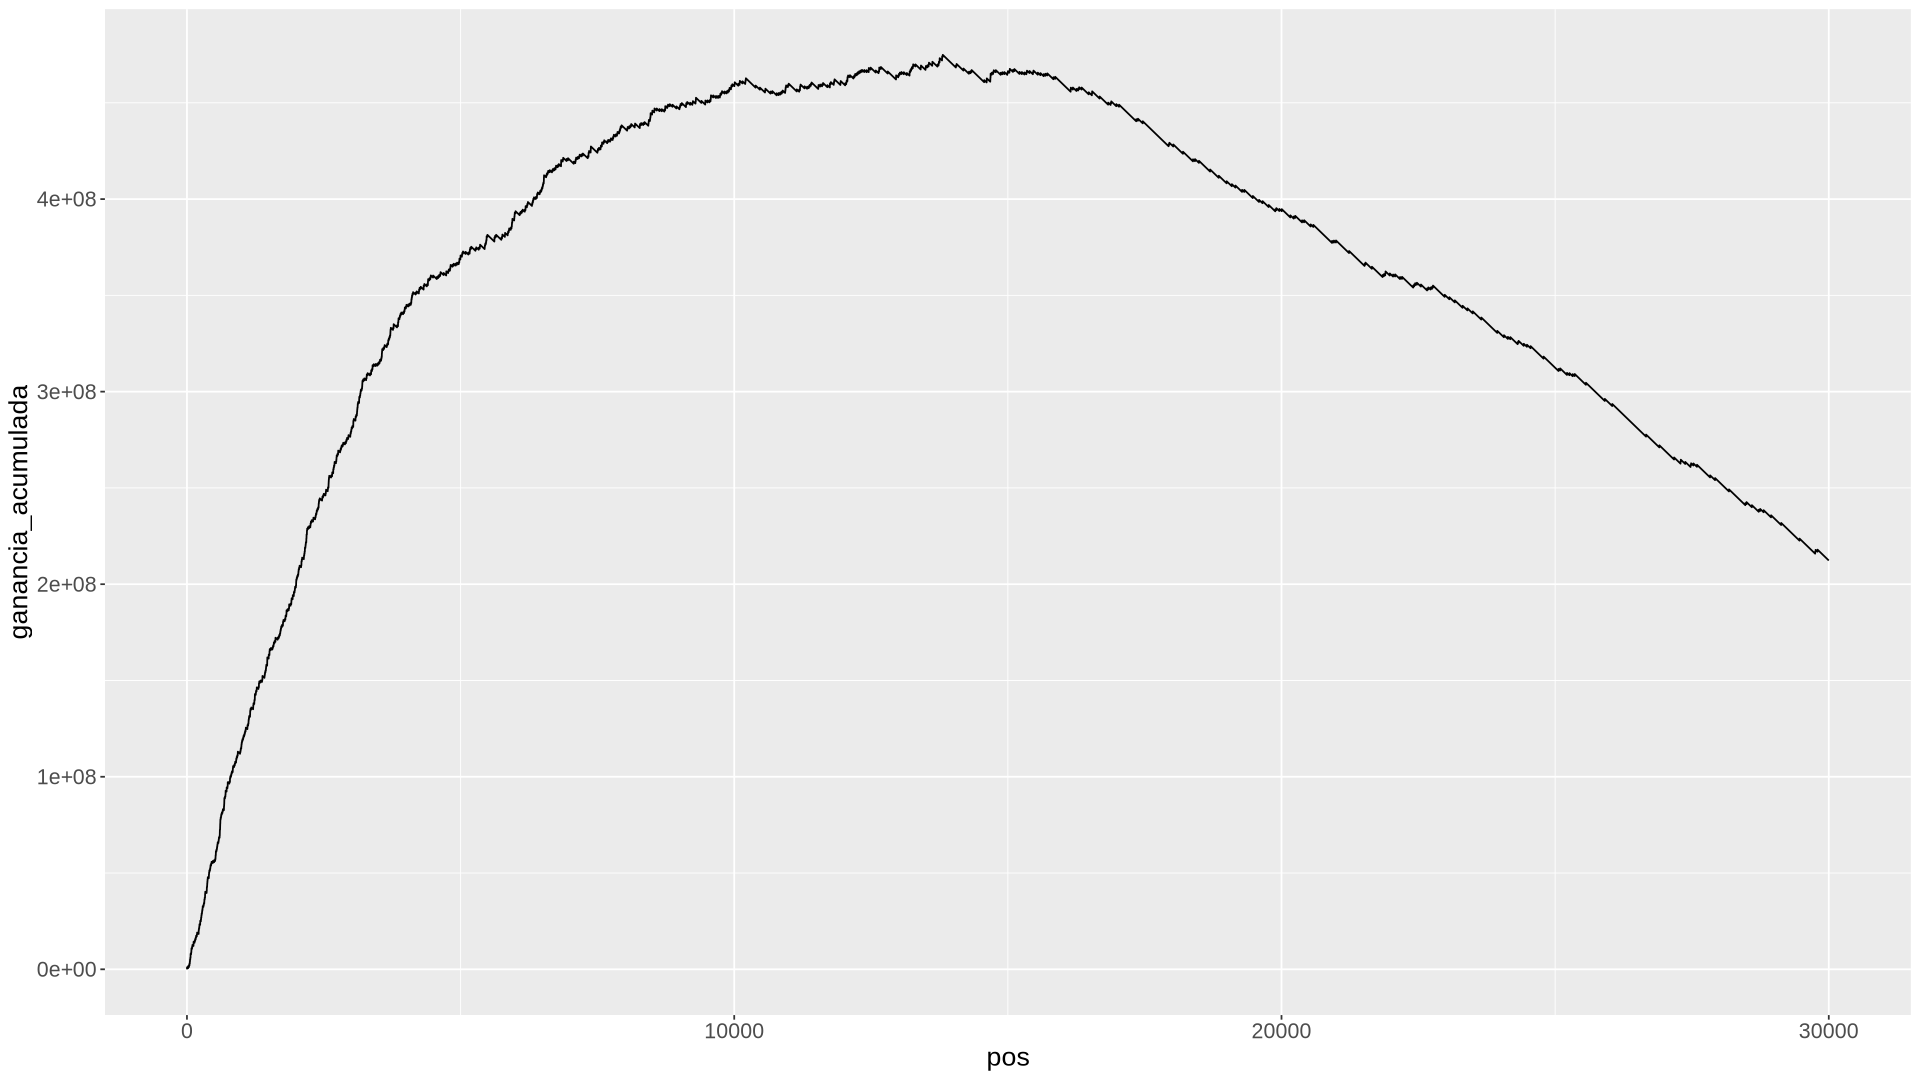

In [22]:
# defino hasta donde muestra el grafico
amostrar <- 30000
# observamos la curva de ganancia
gra <- ggplot(
           data= tb_prediccion[pos <= amostrar],
           aes( x= pos, y= ganancia_acumulada)
             ) + geom_line()

gra <- gra + theme(text = element_text(size = 16))

options(repr.plot.width=16, repr.plot.height=9)
print( gra )

In [23]:
# for (envios in cortes) {
#   ganancia <- tb_prediccion[1:envios, sum(gan)]
#   cat( envios, "\t", ganancia, "\n")
# }

# Guardamos resultados

In [24]:
if (file.exists(archivo_validaciones)) {
  validaciones_previas <- fread(archivo_validaciones)
  id_validacion <- max(validaciones_previas$id_validacion) + 1L
} else {
  id_validacion <- 1L
}

registro_validacion <- data.table(
  id_validacion = id_validacion,
  ganancia = max(tb_prediccion$ganancia_acumulada),
  dataset = dataset_file,
  cantidad_registros_totales = nrow(dataset),
  cantidad_registros_entrenamiento = nrow(dataset_train),
  cantidad_registros_validacion = nrow(dfuture),
  meses_entrenamiento = paste(train_final, collapse = ","),
  meses_validacion = paste(future, collapse = ","),
  columnas_excluidas = paste(columnas_excluir, collapse = ","),
  benchmark_original = benchmark_base
)

fwrite(
  registro_validacion,
  archivo_validaciones,
  append = file.exists(archivo_validaciones),
  col.names = !file.exists(archivo_validaciones)
)

# Guarda exactamente los parámetros enviados a lgb.train()
saveRDS(
  params_completos,
  file.path(carpeta_man_val, paste0(id_validacion, ".rds"))
)

# Historico

In [25]:
historico <- fread(archivo_validaciones)
historico

id_validacion,ganancia,dataset,cantidad_registros_totales,cantidad_registros_entrenamiento,cantidad_registros_validacion,meses_entrenamiento,meses_validacion,columnas_excluidas,benchmark_original
<int>,<int>,<chr>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>
1,471405000,competencia_01_ternaria_lags.csv,983061,163284,164114,202104,202106,"ternaria,ternaria_lag1,clase01,fold,azar,training,cprestamos_personales,mprestamos_personales,cprestamos_personales_lag1,mprestamos_personales_lag1,cprestamos_personales_delta1,mprestamos_personales_delta1",benchmark_multisemilla_lags20260921_124327
2,452017500,competencia_01_ternaria_lf_k6_perdida4.csv,983061,163284,164114,202104,202106,"ternaria,clase01,fold,azar,training,cprestamos_personales,mprestamos_personales,cprestamos_personales_lag_pond,mprestamos_personales_lag_pond,cprestamos_personales_delta_lag_pond,mprestamos_personales_delta_lag_pond",benchmark_multisemilla_lags20260921_124327
3,397952500,competencia_01_ternaria_lags.csv,983061,163284,164114,202104,202106,"ternaria,ternaria_lag1,clase01,fold,azar,training",benchmark_multisemilla_lags20260921_124327
4,471872500,competencia_01_ternaria_lags.csv,983061,163284,164114,202104,202106,"ternaria,ternaria_lag1,clase01,fold,azar,training,cprestamos_personales,mprestamos_personales,cprestamos_personales_lag1,mprestamos_personales_lag1,cprestamos_personales_delta1,mprestamos_personales_delta1",benchmark_multisemilla_lags20260921_110853
5,457242500,competencia_01_ternaria_lf_k6_perdida4.csv,983061,163284,164114,202104,202106,"ternaria,ternaria_lag1,clase01,fold,azar,training,cprestamos_personales,mprestamos_personales,cprestamos_personales_lag_pond,mprestamos_personales_lag_pond,cprestamos_personales_delta_lag_pond,mprestamos_personales_delta_lag_pond",benchmark_multisemilla_lags20260921_110853
6,460295000,competencia_01_ternaria_lf_k6_perdida4.csv,983061,163284,164114,202104,202106,"ternaria,ternaria_lag1,clase01,fold,azar,training,cprestamos_personales,mprestamos_personales,cprestamos_personales_lag1,mprestamos_personales_lag1,cprestamos_personales_delta1,mprestamos_personales_delta1,cprestamos_personales_lag_pond,mprestamos_personales_lag_pond,cprestamos_personales_delta_lag_pond,mprestamos_personales_delta_lag_pond",benchmark_multisemilla_lags20260921_151032
7,466400000,competencia_01_ternaria_lags.csv,983061,163284,164114,202104,202106,"ternaria,ternaria_lag1,clase01,fold,azar,training,cprestamos_personales,mprestamos_personales,cprestamos_personales_lag1,mprestamos_personales_lag1,cprestamos_personales_delta1,mprestamos_personales_delta1,cprestamos_personales_lag_pond,mprestamos_personales_lag_pond,cprestamos_personales_delta_lag_pond,mprestamos_personales_delta_lag_pond",benchmark_multisemilla_lags20260921_151032
8,464007500,competencia_01_ternaria_lags.csv,983061,163284,164114,202104,202106,"ternaria,ternaria_lag1,clase01,fold,azar,training,cprestamos_personales,mprestamos_personales,cprestamos_personales_lag1,mprestamos_personales_lag1,cprestamos_personales_delta1,mprestamos_personales_delta1,cprestamos_personales_lag_pond,mprestamos_personales_lag_pond,cprestamos_personales_delta_lag_pond,mprestamos_personales_delta_lag_pond",benchmark_multisemilla_lags20260921_153324
9,460267500,competencia_01_ternaria_lf_k6_perdida4.csv,983061,163284,164114,202104,202106,"ternaria,ternaria_lag1,clase01,fold,azar,training,cprestamos_personales,mprestamos_personales,cprestamos_personales_lag1,mprestamos_personales_lag1,cprestamos_personales_delta1,mprestamos_personales_delta1,cprestamos_personales_lag_pond,mprestamos_personales_lag_pond,cprestamos_personales_delta_lag_pond,mprestamos_personales_delta_lag_pond",benchmark_multisemilla_lags20260921_153324


# LEER PARAMS COMPLETOS

In [26]:
id = 24
params_completos_4 <- readRDS(
  file.path(carpeta_man_val, paste0(id, ".rds"))
)
params_completos_25 <- readRDS(
  file.path(carpeta_man_val, paste0(16, ".rds"))
)


In [27]:
for (nombre in names(params_completos_4)) {
  # %-25s significa: texto alineado a la izquierda con 25 caracteres de ancho
  cat(sprintf("%-25s ->  %-25s | %-25s\n", 
              nombre, 
              as.character(params_completos_4[[nombre]]), 
              as.character(params_completos_14[[nombre]])))
}

ERROR: Error in eval(expr, envir, enclos): object 'params_completos_14' not found
